In [42]:
import numpy as np

import multi_aster_spindle as mas
import fit_mt_length_histogram as fmlh

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import argparse
import glob
import os

ceph = '/mnt/home/ealca/ceph/'
home = '/mnt/home/ealca/'

# exp_dir = f'{ceph}multi_aster/useful/spindle_centring_10.0_lbar_5000_tubulin_0.0005_temp'
# exp_dir = f'{ceph}multi_aster/dt-L/single_aster_positioning_2500_tubulin_0.0005_temp'
# exp_dir = f'{ceph}multi_aster/useful/single_aster_positioning_reduced_tub_cost_1000_tubulin_0.002_temp'
# exp_dir = f'{ceph}multi_aster/dt-L/uniform_13_dbar_10000_tubulin_0.0001_temp/'
# exp_dir = f'{ceph}multi_aster/dt-L/test_new_saving_13_dbar_10000_tubulin_0.0002_temp/'
exp_dir = f'{ceph}multi_aster/dt-L/set_length_alignment_zero_force_13_dbar_10000_tubulin_0.0005_temp/'

spindle = mas.retrieve_experiement(experiment_dir=exp_dir, save_trajectory=True)

start_time = 75
end_time = 175

6770122


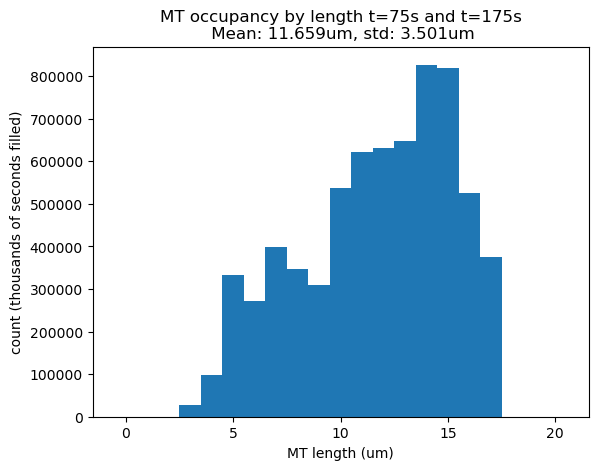

In [43]:
def calculate_mt_lengths(mtoc_index, start_time, end_time):
    start_idx = int(start_time / spindle.evolution_time)
    end_idx = int(end_time / spindle.evolution_time)

    spindle_trace_dir = os.path.join(spindle.dir_path, 'spindle_trace')
    trace_files = sorted(
        glob.glob(os.path.join(spindle_trace_dir, 'spindle_trace_*.npy')),
        key=lambda f: int(os.path.basename(f).split('_')[2])
    )

    pull_state = np.zeros(spindle.num_pull_sites)
    lengths = []
    delta_idx = 0

    for trace_file in trace_files:
        changes = np.load(trace_file, allow_pickle=True)
        for push, lattice_site, site_value in changes:
            if delta_idx >= end_idx:
                break
            if not push:
                pull_state[int(lattice_site)] = site_value
            if delta_idx >= start_idx:
                pulling_sites = spindle.pull_lattice[pull_state == mtoc_index]
                if len(pulling_sites) > 0:
                    lengths.extend(mas.normalize_vecs(pulling_sites - spindle.mtoc_positions[mtoc_index])[1])
            delta_idx += 1
        if delta_idx >= end_idx:
            break

    return lengths


pulling_mt_lengths = calculate_mt_lengths(1, start_time, end_time)
pulling_mt_lengths.extend(calculate_mt_lengths(2, start_time, end_time))

print(len(pulling_mt_lengths))

centers = np.arange(0, 21)
edges = centers - 0.5
edges = np.append(edges, 20.5)

fig, ax = plt.subplots()
ax.set_title(f'MT occupancy by length t={start_time}s and t={end_time}s\n Mean: {np.round(np.mean(pulling_mt_lengths),3)}um, std: {np.round(np.std(pulling_mt_lengths),3)}um')
ax.hist(pulling_mt_lengths, bins=edges)
ax.set_ylabel('count (thousands of seconds filled)')
ax.set_xlabel('MT length (um)')
plt.show()

In [44]:
# results = fmlh.analyze_exponential(pulling_mt_lengths, alpha=1.0, show_plots=True)

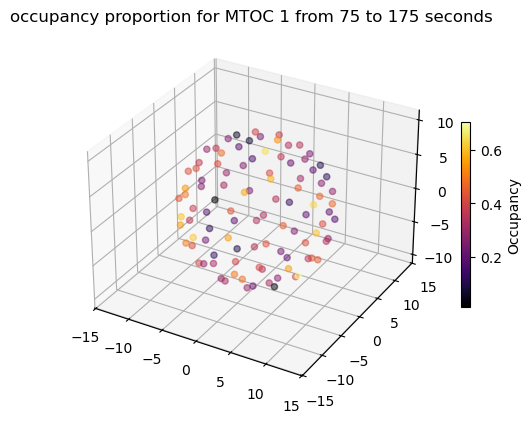

In [45]:
# -- plot heatmap of motor occupancy
pull_lattice = spindle.pull_lattice

xs = pull_lattice[:,0]
ys = pull_lattice[:,1]
zs = pull_lattice[:,2]

# start_time = 55
# end_time = 140

occupancy = spindle.calculate_motor_occupancy(1, start_time, end_time)
norm = mcolors.Normalize(vmin=occupancy.min(), vmax=occupancy.max())

cmap = plt.cm.inferno
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.title(f'occupancy proportion for MTOC 1 from {start_time} to {end_time} seconds')

ax.scatter(xs, ys, zs, c=occupancy,alpha=0.5, cmap=cmap, norm=norm)
ax.axis('equal')

mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array(occupancy)
fig.colorbar(mappable, ax=ax, shrink=0.5, label="Occupancy")
plt.show()

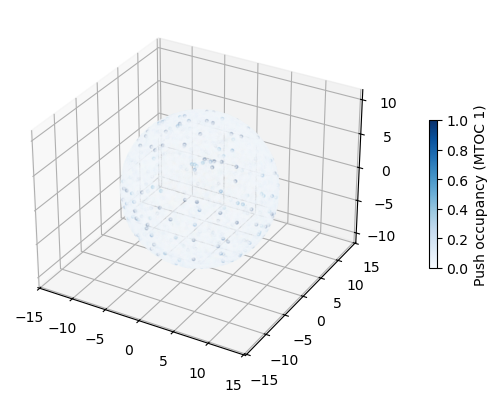

In [46]:
occupancy = spindle.calculate_push_occupancy(1, start_time, end_time)
norm = mcolors.Normalize(vmin=occupancy.min(), vmax=occupancy.max())

push_cmap = plt.cm.Blues
push_occ_norm = mcolors.Normalize(vmin=0, vmax=max(occupancy.max(), 1e-9))
px, py, pz = spindle.push_lattice[:, 0], spindle.push_lattice[:, 1], spindle.push_lattice[:, 2]

def _push_rgba(occ):
    rgba = push_cmap(push_occ_norm(occ))
    rgba[occ == 0, 3] = 0    # transparent where never occupied
    rgba[occ > 0, 3] = 0.2   # low alpha for occupied push sites
    return rgba

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
push_occ_scatter = ax.scatter(px, py, pz, c=_push_rgba(occupancy), s=5)
fig.colorbar(plt.cm.ScalarMappable(norm=push_occ_norm, cmap=push_cmap), ax=ax, shrink=0.4, pad=0.10, label=f'Push occupancy (MTOC {1})')

ax.axis('equal')
plt.show()

In [4]:
def calculate_pulling_mt_lengths_at_birth(mtoc_index, start_time, end_time):
    start_idx = int(start_time / spindle.evolution_time)
    end_idx = int(end_time / spindle.evolution_time)

    spindle_trace_dir = os.path.join(spindle.dir_path, 'spindle_trace')
    trace_files = sorted(
        glob.glob(os.path.join(spindle_trace_dir, 'spindle_trace_*.npy')),
        key=lambda f: int(os.path.basename(f).split('_')[2])
    )

    times = np.array(list(spindle.trajectory.keys()))
    pull_state = np.zeros(spindle.num_pull_sites, dtype=int)
    birth_lengths = []
    delta_idx = 0

    for trace_file in trace_files:
        changes = np.load(trace_file, allow_pickle=True)
        for push, lattice_site, site_value in changes:
            if delta_idx >= end_idx:
                break
            lattice_site = int(lattice_site)
            site_value = int(site_value)
            if not push and delta_idx >= start_idx:
                if pull_state[lattice_site] == 0 and site_value == mtoc_index:
                    time_of_birth = times[delta_idx]
                    mtoc_pos_at_birth = spindle.trajectory[time_of_birth]['mtoc_pos'][mtoc_index]
                    landing_site = spindle.pull_lattice[lattice_site]
                    birth_lengths.append(mas.normalize_vecs(mtoc_pos_at_birth - landing_site)[1])
            if not push:
                pull_state[lattice_site] = site_value
            delta_idx += 1
        if delta_idx >= end_idx:
            break

    return np.array(birth_lengths)


# pulling_lengths_at_birth = calculate_pulling_mt_lengths_at_birth(1, start_time, end_time)

# print(f'mean MT length at birth: {np.mean(pulling_lengths_at_birth)}, std: {np.std(pulling_lengths_at_birth)}')

# centers = np.arange(0, 21)
# edges = centers - 0.5
# edges = np.append(edges, 20.5)

# fig, ax = plt.subplots()
# ax.set_title(f'MT lengths at birth between t={start_time} and t={end_time}\n Mean: {np.round(np.mean(pulling_lengths_at_birth),3)}, std: {np.round(np.std(pulling_lengths_at_birth),3)}')
# ax.hist(pulling_lengths_at_birth, bins=edges)
# ax.set_ylabel('count')
# ax.set_xlabel('MT length (um)')
# plt.show()

IndexError: index 75221 is out of bounds for axis 0 with size 48000

In [ ]:
# results = fmlh.analyze_exponential(pulling_mt_lengths_at_birth, alpha=1.0, show_plots=True)

In [ ]:
def calculate_pulling_mt_lengths_at_death(mtoc_index, start_time, end_time):
    start_idx = int(start_time / spindle.evolution_time)
    end_idx = int(end_time / spindle.evolution_time)

    spindle_trace_dir = os.path.join(spindle.dir_path, 'spindle_trace')
    trace_files = sorted(
        glob.glob(os.path.join(spindle_trace_dir, 'spindle_trace_*.npy')),
        key=lambda f: int(os.path.basename(f).split('_')[2])
    )

    times = np.array(list(spindle.trajectory.keys()))
    pull_state = np.zeros(spindle.num_pull_sites, dtype=int)
    death_lengths = []
    delta_idx = 0

    for trace_file in trace_files:
        changes = np.load(trace_file, allow_pickle=True)
        for push, lattice_site, site_value in changes:
            if delta_idx >= end_idx:
                break
            lattice_site = int(lattice_site)
            site_value = int(site_value)
            if not push and delta_idx >= start_idx:
                if pull_state[lattice_site] == mtoc_index and site_value == 0:
                    time_of_death = times[delta_idx]
                    mtoc_pos_at_death = spindle.trajectory[time_of_death]['mtoc_pos'][mtoc_index]
                    landing_site = spindle.pull_lattice[lattice_site]
                    death_lengths.append(mas.normalize_vecs(mtoc_pos_at_death - landing_site)[1])
            if not push:
                pull_state[lattice_site] = site_value
            delta_idx += 1
        if delta_idx >= end_idx:
            break

    return np.array(death_lengths)


# pulling_lengths_at_death = calculate_pulling_mt_lengths_at_death(1, start_time, end_time)

# print(f'mean MT length at death: {np.mean(pulling_lengths_at_death)}, std: {np.std(pulling_lengths_at_death)}')

# fig, ax = plt.subplots()
# ax.set_title(f'MT lengths at death between t={start_time} and t={end_time}\n Mean: {np.round(np.mean(pulling_lengths_at_death),3)}, std: {np.round(np.std(pulling_lengths_at_death),3)}')
# ax.hist(pulling_lengths_at_death, bins=edges)
# ax.set_ylabel('count')
# ax.set_xlabel('MT length (um)')
# plt.show()

In [ ]:
# ani_path = os.path.join(spindle.plot_folder_path, f'occupancy_ani.mp4')
# spindle.animate_mtoc_trajectory(save_path=ani_path, interval=50, stride=200, show_occupancy=True, occupancy_mtoc_id=1)

# spindle.optimize(10000000)

# spindle.plot_cost()